#Mobile Legends: Bang Bang - Exploratory Data Analysis

**Author:** Biju

**Project:** Analyzing hero stats, roles, and meta trends in Mobile Legends

##Objectives
1. Understand the hero roster - roles, classes, lanes
2. Identify stat patterns across hero types
3. Find which heroes/roles are statistically strongest
4. Visualize key findings


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded")

Libraries loaded


In [15]:
# Step 1: Install Kaggle and upload your API key
!pip install kaggle -q

from google.colab import files
print("Click 'Choose Files' below and upload your kaggle.json file:")
uploaded = files.upload()

Click 'Choose Files' below and upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [16]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API configured")

Kaggle API configured


In [17]:
!kaggle datasets download -d kishan9044/mobile-legends-bang-bang
!unzip -o mobile-legends-bang-bang.zip
!ls -la *.csv

Dataset URL: https://www.kaggle.com/datasets/kishan9044/mobile-legends-bang-bang
License(s): CC0-1.0
100% 5.49k/5.49k [00:00<00:00, 12.1MB/s]

Archive:  mobile-legends-bang-bang.zip
  inflating: Mlbb_Heroes.csv         
-rw-r--r-- 1 root root 12824 Sep 24  2022 Mlbb_Heroes.csv


In [19]:
df = pd.read_csv("Mlbb_Heroes.csv")

print(f"Loaded {df.shape[0]} heroes with {df.shape[1]} columns\n")
print("Column names:")
print(df.columns.tolist())
print("\nFirst 5 heroes:")
df.head()

Loaded 114 heroes with 18 columns

Column names:
['Name', 'Title', 'Voice_Line', 'Release_Date', 'Primary_Role', 'Secondary_Role', 'Lane', 'Hp', 'Hp_Regen', 'Mana', 'Mana_Regen', 'Phy_Damage', 'Mag_Damage', 'Phy_Defence', 'Mag_Defence', 'Mov_Speed', 'Esport_Wins', 'Esport_Loss']

First 5 heroes:


,Name,Title,Voice_Line,Release_Date,Primary_Role,Secondary_Role,Lane,Hp,Hp_Regen,Mana,Mana_Regen,Phy_Damage,Mag_Damage,Phy_Defence,Mag_Defence,Mov_Speed,Esport_Wins,Esport_Loss
0,Aamon,Duke of Shards,"It is better to be feared than loved, if you c...",2021-10-25,Assassin,NaN,Jungler,2614,8.0,455,21.0,115,0,19,15,250,43,42
1,Akai,Panda Warrior,Now Akai enters the scene!,2016,Tank,Support,Roamer,2769,8.4,422,12.0,115,0,24,15,260,540,524
2,Aldous,Soul Contractor,Primary Role,2018,Fighter,NaN,EXP Lane,2718,9.8,405,18.0,129,0,21,15,260,95,92
3,Alice,Queen of Blood,Watch your back!,2016,Mage,Tank,EXP Lane,2573,7.2,493,18.0,114,0,21,15,240,364,352
4,Alpha,Blade of Enmity,Test! Alpha is online.,2017,Fighter,NaN,EXP Lane,2646,7.8,453,31.0,121,0,25,15,260,24,33


In [20]:
# See ALL 18 columns (the first view cut some off)
pd.set_option('display.max_columns', None)
df.head()

,Name,Title,Voice_Line,Release_Date,Primary_Role,Secondary_Role,Lane,Hp,Hp_Regen,Mana,Mana_Regen,Phy_Damage,Mag_Damage,Phy_Defence,Mag_Defence,Mov_Speed,Esport_Wins,Esport_Loss
0,Aamon,Duke of Shards,"It is better to be feared than loved, if you c...",2021-10-25,Assassin,NaN,Jungler,2614,8.0,455,21.0,115,0,19,15,250,43,42
1,Akai,Panda Warrior,Now Akai enters the scene!,2016,Tank,Support,Roamer,2769,8.4,422,12.0,115,0,24,15,260,540,524
2,Aldous,Soul Contractor,Primary Role,2018,Fighter,NaN,EXP Lane,2718,9.8,405,18.0,129,0,21,15,260,95,92
3,Alice,Queen of Blood,Watch your back!,2016,Mage,Tank,EXP Lane,2573,7.2,493,18.0,114,0,21,15,240,364,352
4,Alpha,Blade of Enmity,Test! Alpha is online.,2017,Fighter,NaN,EXP Lane,2646,7.8,453,31.0,121,0,25,15,260,24,33


In [21]:
# Get a summary of the dataset structure
print("=== Dataset Info ===\n")
df.info()

=== Dataset Info ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            114 non-null    object 
 1   Title           114 non-null    object 
 2   Voice_Line      114 non-null    object 
 3   Release_Date    114 non-null    object 
 4   Primary_Role    114 non-null    object 
 5   Secondary_Role  30 non-null     object 
 6   Lane            114 non-null    object 
 7   Hp              114 non-null    int64  
 8   Hp_Regen        114 non-null    float64
 9   Mana            114 non-null    int64  
 10  Mana_Regen      113 non-null    float64
 11  Phy_Damage      114 non-null    int64  
 12  Mag_Damage      114 non-null    int64  
 13  Phy_Defence     114 non-null    int64  
 14  Mag_Defence     114 non-null    int64  
 15  Mov_Speed       114 non-null    int64  
 16  Esport_Wins     114 non-null    int64  
 17  Esport_Loss  

In [22]:
# Count missing values per column
print("=== Missing values per column ===\n")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nTotal heroes: {len(df)}")

=== Missing values per column ===

Secondary_Role    84
Mana_Regen         1
dtype: int64

Total heroes: 114


In [23]:
# Find the hero with missing Mana_Regen
missing_mana = df[df['Mana_Regen'].isnull()]
print("Hero(es) with missing Mana_Regen:")
print(missing_mana[['Name', 'Primary_Role', 'Mana', 'Mana_Regen']])

Hero(es) with missing Mana_Regen:
    Name Primary_Role  Mana  Mana_Regen
108  Yin      Fighter     0         NaN


In [25]:
#clean the data
df['Secondary_Role'] = df['Secondary_Role'].fillna('None')
df['Mana_Regen'] = df['Mana_Regen'].fillna(0)

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "missing values remaining")
print("\nSecondary_Role distribution:")
print(df['Secondary_Role'].value_counts())

Missing values after cleaning:
0 missing values remaining

Secondary_Role distribution:
Secondary_Role
None        84
Support      7
Tank         6
Assassin     6
Mage         5
Fighter      3
Marksman     3
Name: count, dtype: int64


/tmp/ipykernel_1815/1274521941.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_counts.index, y=role_counts.values, palette='viridis')


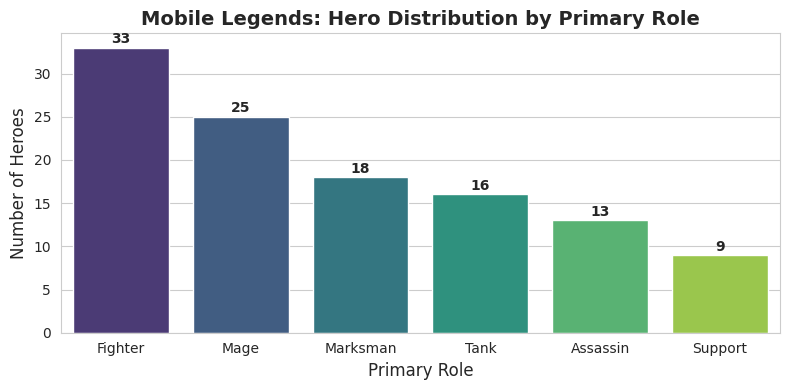


📊 Most common role: Fighter (33 heroes)


In [28]:
#vissualization
import matplotlib.pyplot as plt
import seaborn as sns

role_counts = df['Primary_Role'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=role_counts.index, y=role_counts.values, palette='viridis')

plt.title('Mobile Legends: Hero Distribution by Primary Role', fontsize=14, fontweight='bold')
plt.xlabel('Primary Role', fontsize=12)
plt.ylabel('Number of Heroes', fontsize=12)

for i, count in enumerate(role_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('hero_role_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Most common role: {role_counts.index[0]} ({role_counts.values[0]} heroes)")